In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
car_sales = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/refs/heads/master/data/car-sales.csv")

In [3]:
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"


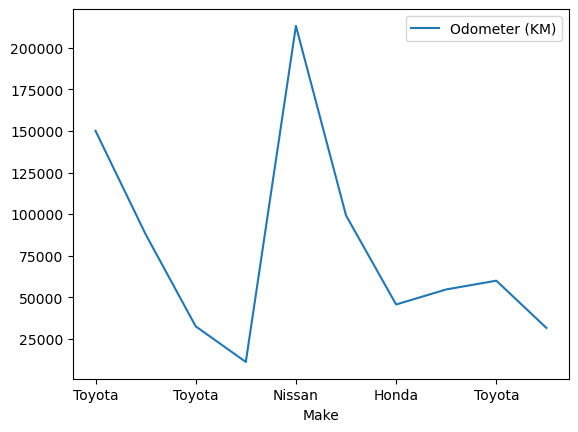

In [4]:
# car_sales["Odometer (KM)"].plot(); # tip: the ";" on the end prevents matplotlib from outputing the plot class
car_sales.plot(x="Make", y="Odometer (KM)"); 

In [5]:
car_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Make           10 non-null     object
 1   Colour         10 non-null     object
 2   Odometer (KM)  10 non-null     int64 
 3   Doors          10 non-null     int64 
 4   Price          10 non-null     object
dtypes: int64(2), object(3)
memory usage: 532.0+ bytes


In [6]:
# Change Price column to integers
car_sales["Price"] = car_sales["Price"].astype(str)

In [7]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [8]:
# Change Price column to integers
car_sales["Price"] = car_sales["Price"].str.replace(r'[\$\,\.]', '', regex=True)

In [9]:
car_sales["Price"] = car_sales["Price"].astype(int) 

In [10]:
car_sales['Price'] = car_sales['Price'] / 100

<Axes: >

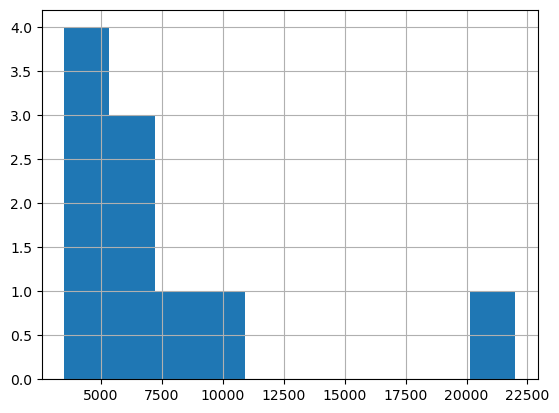

In [11]:
car_sales['Price'].hist()

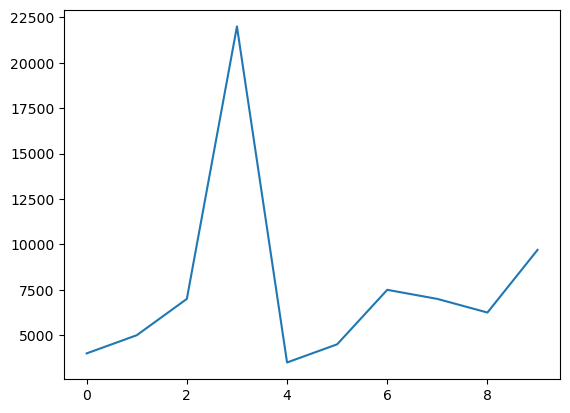

In [12]:
car_sales["Price"].plot();

## Manipulation

##### To do so you could use .sample(frac=1).

##### .sample() randomly samples different rows from a DataFrame.

###### The frac parameter dictates the fraction, where 1 = 100% of rows, 0.5 = 50% of rows, 0.01 = 1% of rows.

##### You can also use .sample(n=1) where n is the number of rows to sample.
###### Notice how the rows remain intact but their order is mixed (check the indexes).

In [13]:
# Sample car_sales
car_sales_sampled = car_sales.sample(frac=1)
car_sales_sampled

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000.0
9,Nissan,White,31600,4,9700.0
5,Toyota,Green,99213,4,4500.0
4,Nissan,White,213095,4,3500.0
2,Toyota,Blue,32549,3,7000.0
6,Honda,Blue,45698,4,7500.0
8,Toyota,White,60000,4,6250.0
7,Honda,Blue,54738,4,7000.0
3,BMW,Black,11179,5,22000.0
1,Honda,Red,87899,4,5000.0


#### Finally, what if you wanted to apply a function to a column. Such as, converting the Odometer column from kilometers to miles.

#### You can do so using the .apply() function and passing it a Python lambda function. 

In [14]:
# Change the Odometer values from kilometres to miles
car_sales['Odometer (Miles)'] = car_sales["Odometer (KM)"].apply(lambda x: x / 1.6)

In [15]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Odometer (Miles)
0,Toyota,White,150043,4,4000.0,93776.875
1,Honda,Red,87899,4,5000.0,54936.875
2,Toyota,Blue,32549,3,7000.0,20343.125
3,BMW,Black,11179,5,22000.0,6986.875
4,Nissan,White,213095,4,3500.0,133184.375
5,Toyota,Green,99213,4,4500.0,62008.125
6,Honda,Blue,45698,4,7500.0,28561.250
7,Honda,Blue,54738,4,7000.0,34211.250
8,Toyota,White,60000,4,6250.0,37500.000
9,Nissan,White,31600,4,9700.0,19750.000


## Introduction of Numpy

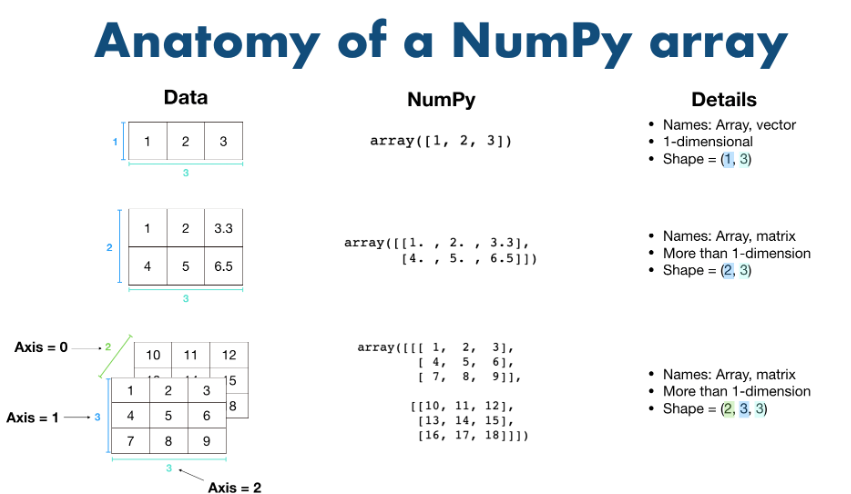

In [16]:
# Numpy's main datatype is ndarray
al = np.array([1, 2, 3])
al

array([1, 2, 3])

In [17]:
# 1-dimensonal array, also referred to as a vector
a1 = np.array([1, 2, 3])

# 2-dimensional array, also referred to as matrix
a2 = np.array([[1, 2.0, 3.3],
               [4, 5, 6.5]])

# 3-dimensional array, also referred to as a matrix
a3 = np.array([[[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]],
                [[10, 11, 12],
                 [13, 14, 15],
                 [16, 17, 18]]])

In [18]:
a1.shape, a1.ndim, a1.dtype, a1.size, type(a1)

((3,), 1, dtype('int64'), 3, numpy.ndarray)

In [19]:
a2.shape, a2.ndim, a2.dtype, a2.size, type(a2)

((2, 3), 2, dtype('float64'), 6, numpy.ndarray)

In [20]:
a3.shape, a3.ndim, a3.dtype, a3.size, type(a3)

((2, 3, 3), 3, dtype('int64'), 18, numpy.ndarray)

In [21]:
# Random array
random_array = np.random.randint(10, size=(5, 3))
random_array

array([[4, 5, 3],
       [1, 0, 7],
       [5, 6, 4],
       [3, 3, 8],
       [7, 7, 0]], dtype=int32)

In [22]:
print(random_array.shape, random_array.size)

(5, 3) 15


In [23]:
# Random array of floats (between 0 & 1)
# np.random.seed(0)}
np.random.random((5, 3))

array([[0.86889713, 0.41045176, 0.54157038],
       [0.93077523, 0.50732501, 0.77528672],
       [0.59139112, 0.25875963, 0.71379145],
       [0.8841616 , 0.57367254, 0.63904843],
       [0.09792205, 0.43995683, 0.58017492]])

##### NumPy uses pseudo-random numbers, which means, the numbers look random but aren't really, they're predetermined.

##### With np.random.seed() set, every time you run the cell above, the same random numbers will be generated.

##### What if np.random.seed() wasn't set? Every time you run the cell below, a new set of numbers will appear.

In [24]:
a4 = np.random.randint(10, size=(2, 3, 4, 5))
# 2 matrices, de 3 capas, de 4 filas por 5 columnas
a4

array([[[[8, 6, 6, 1, 7],
         [3, 0, 1, 9, 0],
         [3, 3, 4, 1, 0],
         [6, 2, 5, 2, 6]],

        [[1, 7, 0, 7, 8],
         [6, 2, 6, 2, 4],
         [6, 6, 5, 5, 5],
         [8, 7, 8, 9, 2]],

        [[1, 9, 8, 4, 2],
         [4, 0, 3, 3, 9],
         [4, 9, 6, 7, 6],
         [9, 4, 4, 6, 0]]],


       [[[2, 4, 7, 4, 5],
         [6, 6, 6, 6, 2],
         [6, 9, 7, 4, 9],
         [7, 8, 5, 7, 5]],

        [[5, 6, 7, 1, 4],
         [8, 1, 0, 6, 8],
         [0, 9, 7, 9, 4],
         [5, 2, 4, 2, 0]],

        [[8, 7, 5, 8, 0],
         [5, 9, 4, 9, 7],
         [9, 6, 9, 4, 3],
         [9, 8, 3, 0, 8]]]], dtype=int32)

In [25]:
a4.shape, a4.ndim

((2, 3, 4, 5), 4)

In [26]:
# Get only the first 4 numbers of each single vector
a4[:, :, :, :4]

array([[[[8, 6, 6, 1],
         [3, 0, 1, 9],
         [3, 3, 4, 1],
         [6, 2, 5, 2]],

        [[1, 7, 0, 7],
         [6, 2, 6, 2],
         [6, 6, 5, 5],
         [8, 7, 8, 9]],

        [[1, 9, 8, 4],
         [4, 0, 3, 3],
         [4, 9, 6, 7],
         [9, 4, 4, 6]]],


       [[[2, 4, 7, 4],
         [6, 6, 6, 6],
         [6, 9, 7, 4],
         [7, 8, 5, 7]],

        [[5, 6, 7, 1],
         [8, 1, 0, 6],
         [0, 9, 7, 9],
         [5, 2, 4, 2]],

        [[8, 7, 5, 8],
         [5, 9, 4, 9],
         [9, 6, 9, 4],
         [9, 8, 3, 0]]]], dtype=int32)

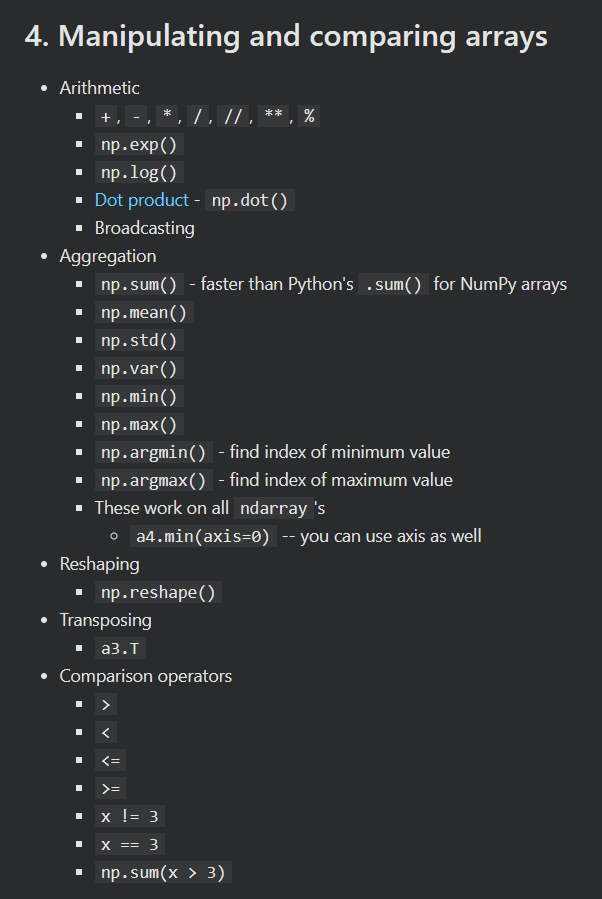

In [27]:
a1

array([1, 2, 3])

In [28]:
a2

array([[1. , 2. , 3.3],
       [4. , 5. , 6.5]])

In [30]:
a3

array([[[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9]],

       [[10, 11, 12],
        [13, 14, 15],
        [16, 17, 18]]])

In [29]:
a1 * a2

array([[ 1. ,  4. ,  9.9],
       [ 4. , 10. , 19.5]])

In [31]:
a2 * 3

array([[ 3. ,  6. ,  9.9],
       [12. , 15. , 19.5]])

In [32]:
# This will error as the arrays have a different number of dimensions (2, 3) vs. (2, 3, 3) 
# a2 * a3

In [33]:
# Divide using floor division that removes decimals (rounds down)
a2 // a1

array([[1., 1., 1.],
       [4., 2., 2.]])

In [34]:
# Take an array to a power
a1 ** 2

# You can also use np.square()
np.square(a1)

array([1, 4, 9])

In [35]:
# Modulus divide (what's the remainder)
a2 % 2

array([[1. , 0. , 1.3],
       [0. , 1. , 0.5]])

In [36]:
# Find the log of an array
np.log(a1)

array([0.        , 0.69314718, 1.09861229])

In [37]:
# Find the exponential of an array
np.exp(a1)

array([ 2.71828183,  7.3890561 , 20.08553692])

### Aggregation
##### bringing things together, doing a similar thing on a number of things.

Use python's methods (`sum()`) on python datatypes and use numpy's methods on numpys arrays (`np.sum()`)

#### Tip: Use NumPy's np.sum() on NumPy arrays and Python's sum() on Python lists

In [38]:
massive_array = np.random.random(100000)
massive_array.size, type(massive_array)

(100000, numpy.ndarray)

In [39]:
massive_array[:10]

array([0.66196006, 0.43831727, 0.76654287, 0.11625502, 0.39616287,
       0.39654773, 0.66599641, 0.16226602, 0.81495784, 0.34548793])

In [40]:
%timeit sum(massive_array) # Python sum()
%timeit np.sum(massive_array) # NumPy np.sum()

6.49 ms ± 253 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
36.5 μs ± 771 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [41]:
print(f"numpy is {(16.2*1000)/37.9:.2f} more faster than python")

numpy is 427.44 more faster than python


In [42]:
import random 
massive_list = [random.randint(0, 10) for i in range(100000)]
len(massive_list), type(massive_list)

(100000, list)

In [43]:
massive_list[:10]

[1, 8, 2, 4, 5, 4, 0, 2, 0, 4]

In [44]:
%timeit sum(massive_list)
%timeit np.sum(massive_list)

414 μs ± 8.46 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.04 ms ± 31.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [45]:
a2

array([[1. , 2. , 3.3],
       [4. , 5. , 6.5]])

In [46]:
# Std deviation = a measure of how spread out a group of numbers is from the mean
# a large spread indicates that there are probably large differences between individual scores.
# std dev is square of variance
np.std(a2)

np.float64(1.8226964152656422)

In [47]:
# Variance = measure of the average degree to which each number is different to the mean
# Higher variance = wider range of number
# Lower variance = lower range of number
np.var(a2)
np.std(a2) == np.sqrt(np.var(a2))

np.True_

What's mean?

Mean is the same as average. You can find the average of a set of numbers by adding them up and dividing them by how many there are.

What's standard deviation?

Standard deviation is a measure of how spread out numbers are.

What's variance?

The variance is the averaged squared differences of the mean.

To work it out, you:

Work out the mean
For each number, subtract the mean and square the result
Find the average of the squared differences

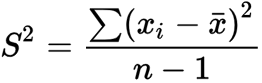

In [48]:
# Demo of variance
high_var_array = np.array([1, 100, 200, 300, 4000, 5000])
low_var_array = np.array([2, 4, 6, 8, 10])

np.var(high_var_array), np.var(low_var_array)

(np.float64(4296133.472222221), np.float64(8.0))

In [49]:
np.std(high_var_array), np.std(low_var_array)

(np.float64(2072.711623024829), np.float64(2.8284271247461903))

In [50]:
np.mean(high_var_array), np.mean(low_var_array)

(np.float64(1600.1666666666667), np.float64(6.0))

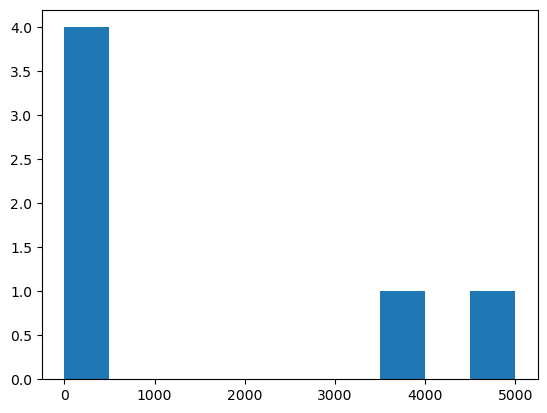

In [51]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(high_var_array)
plt.show()

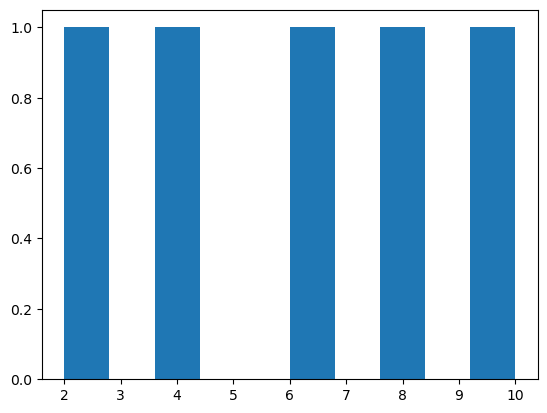

In [52]:
plt.hist(low_var_array)
plt.show()

### Reshaping & transposing

In [53]:
print(a2)

[[1.  2.  3.3]
 [4.  5.  6.5]]


In [54]:
a2.shape, a3.shape

((2, 3), (2, 3, 3))

In [56]:
a2*a3 # means try to do some operations with dimensions incompatible

ValueError: operands could not be broadcast together with shapes (2,3) (2,3,3) 

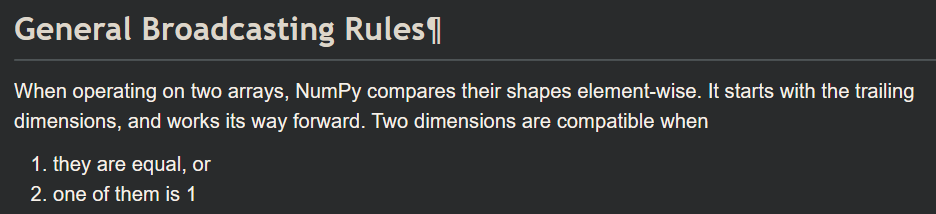

In [57]:
a2.reshape(2, 3, 1)

array([[[1. ],
        [2. ],
        [3.3]],

       [[4. ],
        [5. ],
        [6.5]]])

In [58]:
a2.reshape(2, 3, 1) * a3

array([[[  1. ,   2. ,   3. ],
        [  8. ,  10. ,  12. ],
        [ 23.1,  26.4,  29.7]],

       [[ 40. ,  44. ,  48. ],
        [ 65. ,  70. ,  75. ],
        [104. , 110.5, 117. ]]])

In [59]:
a3.shape

(2, 3, 3)

In [60]:
# Transponse = switches the axis
a3.T.shape

(3, 3, 2)

In [61]:
matrix = np.random.random(size=(5, 3, 3))
matrix

array([[[0.77248678, 0.38186466, 0.85980981],
        [0.98197426, 0.4321249 , 0.43661462],
        [0.18725083, 0.20347051, 0.28024247]],

       [[0.17660139, 0.29212884, 0.79655383],
        [0.96539936, 0.70560148, 0.58051802],
        [0.46339569, 0.29327714, 0.23582504]],

       [[0.04859673, 0.98810435, 0.21287359],
        [0.11522085, 0.20576253, 0.90407613],
        [0.81326392, 0.26609638, 0.07045067]],

       [[0.26145876, 0.35116398, 0.23498634],
        [0.60800984, 0.59135671, 0.19376718],
        [0.73701436, 0.71430914, 0.29508131]],

       [[0.96647206, 0.18144679, 0.29898304],
        [0.79187556, 0.54349007, 0.30753348],
        [0.77364323, 0.41001234, 0.60543766]]])

In [62]:
# Check to see if the reverse shape is same as tranpose shape
matrix.T.shape == matrix.shape[::-1]

True

In [63]:
# Check to see if the first and last axes are swapped
matrix.T == matrix.swapaxes(0, -1) # swap first (0) and last (-1) axes

array([[[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True]],

       [[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True]],

       [[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True]]])

# Dot product

In [64]:
np.random.seed(0) # Con la misma semilla, el algoritmo produce la misma secuencia de números aleatorios en este caso cada vez. 

mat1 = np.random.randint(10, size=(5, 3))
mat2 = np.random.randint(10, size=(5, 3))

In [65]:
mat1

array([[5, 0, 3],
       [3, 7, 9],
       [3, 5, 2],
       [4, 7, 6],
       [8, 8, 1]], dtype=int32)

In [66]:
mat2

array([[6, 7, 7],
       [8, 1, 5],
       [9, 8, 9],
       [4, 3, 0],
       [3, 5, 0]], dtype=int32)

In [67]:
mat1.shape, mat2.shape

((5, 3), (5, 3))

In [68]:
# Element wise multiplication (Hadamard product)
mat1 * mat2

array([[30,  0, 21],
       [24,  7, 45],
       [27, 40, 18],
       [16, 21,  0],
       [24, 40,  0]], dtype=int32)

In [69]:
# Dot product
np.dot(mat1, mat2)

ValueError: shapes (5,3) and (5,3) not aligned: 3 (dim 1) != 5 (dim 0)

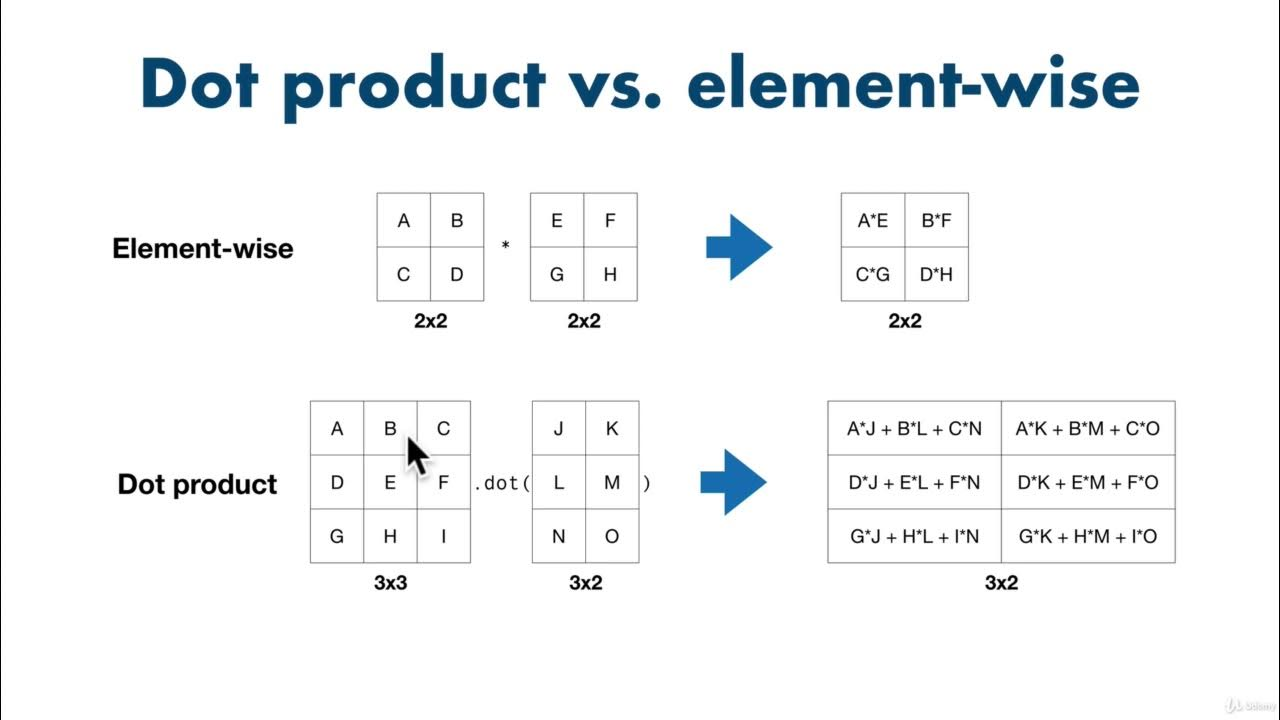 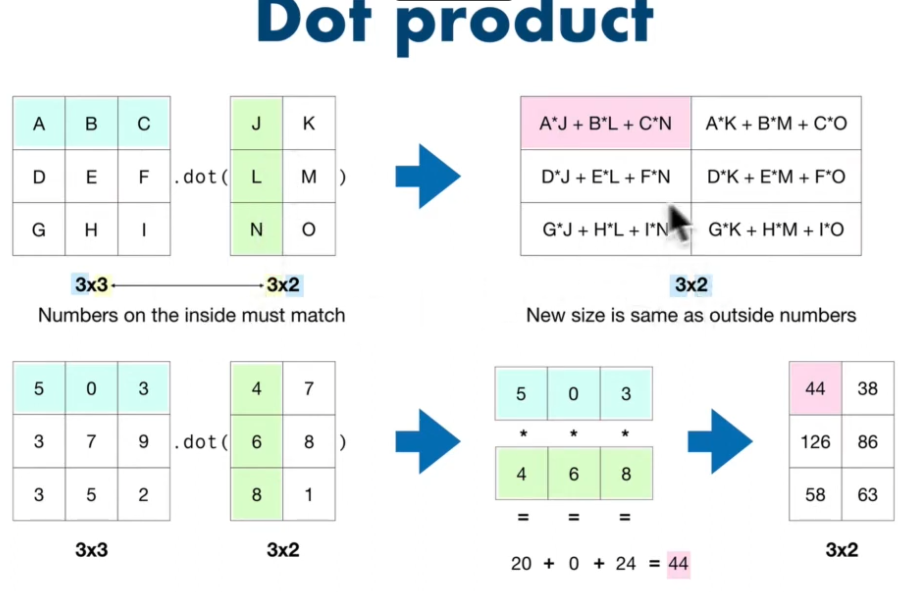

In [70]:
np.dot(mat1.T, mat2)

array([[121, 114,  77],
       [153, 108,  80],
       [135,  69,  84]], dtype=int32)

## Dot product practical example, nut butter sales

In [71]:
np.random.seed(0)  # Con la misma semilla, el algoritmo produce la misma secuencia de números aleatorios en este caso cada vez. 
sales_amounts = np.random.randint(20, size=(5, 3))
sales_amounts

array([[12, 15,  0],
       [ 3,  3,  7],
       [ 9, 19, 18],
       [ 4,  6, 12],
       [ 1,  6,  7]], dtype=int32)

In [72]:
weekly_sales = pd.DataFrame(sales_amounts,
                            index=["Mon", "Tues", "Wed", "Thurs", "Fri"],
                            columns=["Almond butter", "Peanut butter", "Cashew butter"])
weekly_sales

,Almond butter,Peanut butter,Cashew butter
Mon,12,15,0
Tues,3,3,7
Wed,9,19,18
Thurs,4,6,12
Fri,1,6,7


In [73]:
prices = np.array([10, 8, 12])
prices

array([10,  8, 12])

In [74]:
butter_prices = pd.DataFrame(prices.reshape(1, 3),
                             index=["Price"],
                             columns=["Almond butter", "Peanut butter", "Cashew butter"])
butter_prices

,Almond butter,Peanut butter,Cashew butter
Price,10,8,12


In [75]:
# Find the total amount of sales for a whole day
total_sales = prices.dot(sales_amounts.T)
total_sales

array([240, 138, 458, 232, 142])

In [76]:
butter_prices.shape, weekly_sales.T.shape

((1, 3), (3, 5))

In [77]:
daily_sales = butter_prices.dot(weekly_sales.T)
daily_sales

,Mon,Tues,Wed,Thurs,Fri
Price,240,138,458,232,142


In [78]:
# Need to transpose again
weekly_sales["Total"] = daily_sales.T
weekly_sales

,Almond butter,Peanut butter,Cashew butter,Total
Mon,12,15,0,240
Tues,3,3,7,138
Wed,9,19,18,458
Thurs,4,6,12,232
Fri,1,6,7,142


# Link para ver comparadores
https://numpy.org/doc/stable/reference/routines.logic.html

# Sorting arrays
#### - np.sort() - sort values in a specified dimension of an array.
#### - np.argsort() - return the indices to sort the array on a given axis.
#### - np.argmax() - return the index/indicies which gives the highest value(s) along an axis.
#### - np.argmin() - return the index/indices which gives the lowest value(s) along an axis.

In [79]:
random_array = np.random.randint(10, size=(3, 5))
random_array, random_array.shape

(array([[7, 8, 1, 5, 9],
        [8, 9, 4, 3, 0],
        [3, 5, 0, 2, 3]], dtype=int32),
 (3, 5))

In [80]:
np.sort(random_array)

array([[1, 5, 7, 8, 9],
       [0, 3, 4, 8, 9],
       [0, 2, 3, 3, 5]], dtype=int32)

In [81]:
np.argsort(random_array) # devuelve la posición de cada número

array([[2, 3, 0, 1, 4],
       [4, 3, 2, 0, 1],
       [2, 3, 0, 4, 1]])

In [82]:
a1

array([1, 2, 3])

In [83]:
np.argsort(a1)

array([0, 1, 2])

In [84]:
np.argmin(a1)

np.int64(0)

In [85]:
np.argmax(a1)

np.int64(2)

In [86]:
random_array

array([[7, 8, 1, 5, 9],
       [8, 9, 4, 3, 0],
       [3, 5, 0, 2, 3]], dtype=int32)

In [87]:
np.argmax(random_array, axis=0) #horizontal, por cada columna toma índice de mayor valor

array([1, 1, 1, 0, 0])

In [88]:
np.argmax(random_array, axis=1) #vertical, por cada fila toma el índice de mayor valor

array([4, 1, 1])

## Turn images to numpy arrays

In [98]:
from matplotlib.image import imread
panda = imread("images/panda.jpeg")
print(type(panda))

<class 'numpy.ndarray'>


In [100]:
panda.size, panda.shape, panda.ndim

(3271680, (852, 1280, 3), 3)

In [101]:
panda[: 5]

array([[[14, 27, 17],
        [14, 27, 17],
        [12, 28, 17],
        ...,
        [42, 35, 25],
        [42, 35, 25],
        [41, 34, 24]],

       [[14, 27, 17],
        [14, 27, 17],
        [12, 28, 17],
        ...,
        [42, 35, 25],
        [42, 35, 25],
        [42, 35, 25]],

       [[13, 26, 16],
        [14, 27, 17],
        [12, 28, 17],
        ...,
        [42, 35, 25],
        [42, 35, 25],
        [42, 35, 25]],

       [[13, 26, 16],
        [14, 27, 17],
        [13, 29, 18],
        ...,
        [42, 35, 25],
        [42, 35, 25],
        [42, 35, 25]],

       [[13, 26, 16],
        [14, 27, 17],
        [13, 29, 18],
        ...,
        [43, 34, 25],
        [42, 33, 24],
        [42, 33, 24]]], shape=(5, 1280, 3), dtype=uint8)